# Dataset to MindRecord Conversion
## With Quality Checks & Visualizations

**Purpose:** Convert Wide&Deep training dataset to MindRecord format for MindSpore

**Steps:**
1. Load CSV and numpy files
2. Analyze original data structure
3. Convert to MindRecord format
4. Verify conversion quality
5. Compare statistics before/after

---

## Setup & Installation

In [1]:
# Install MindSpore if not already installed
import sys
try:
    import mindspore
    print(f"✓ MindSpore already installed: {mindspore.__version__}")
except ImportError:
    print("Installing MindSpore...")
    !pip install mindspore==2.2.14 --quiet
    import mindspore
    print(f"✓ MindSpore installed: {mindspore.__version__}")

✓ MindSpore already installed: 2.8.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from collections import Counter
import warnings

from mindspore.mindrecord import FileWriter
from mindspore.mindrecord import FileReader

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

# Paths
data_dir = Path('/workspace/data/processed')
output_dir = Path('/workspace/data/mindrecord')
viz_dir = Path('/workspace/data/visualizations/mindrecord')

output_dir.mkdir(parents=True, exist_ok=True)
viz_dir.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")
print(f"  Data directory: {data_dir}")
print(f"  Output directory: {output_dir}")
print(f"  Visualization directory: {viz_dir}")

✓ Setup complete
  Data directory: /workspace/data/processed
  Output directory: /workspace/data/mindrecord
  Visualization directory: /workspace/data/visualizations/mindrecord


---
## Step 1: Load Original Dataset

In [3]:
print("="*80)
print("LOADING ORIGINAL DATASET")
print("="*80)

# Load CSV
df = pd.read_csv(data_dir / 'unified_training_dataset_v3.csv')
print(f"\n✓ Loaded training data: {df.shape}")

# Load skill vectors
user_skill_vectors = np.load(data_dir / 'user_skill_vectors.npy')
sim_skill_vectors = np.load(data_dir / 'simulation_skill_vectors.npy')
print(f"✓ Loaded user skill vectors: {user_skill_vectors.shape}")
print(f"✓ Loaded simulation skill vectors: {sim_skill_vectors.shape}")

# Load label encoders
with open(data_dir / 'label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)
print(f"✓ Loaded label encoders: {len(encoders)} encoders")

# Load catalogs
df_skills = pd.read_csv(data_dir / 'skills_catalog.csv')
df_sims = pd.read_csv(data_dir / 'simulation_catalog.csv')
print(f"✓ Loaded skills catalog: {len(df_skills)} skills")
print(f"✓ Loaded simulation catalog: {len(df_sims)} simulations")

print(f"\nDataset Statistics:")
print(f"  Total samples: {len(df):,}")
print(f"  Positive samples: {df['label'].sum():,}")
print(f"  Negative samples: {(df['label']==0).sum():,}")
print(f"  Positive rate: {df['label'].mean()*100:.2f}%")
print(f"  Unique users: {df['user_id'].nunique():,}")
print(f"  Unique simulations: {df['simulation_id'].nunique()}")

LOADING ORIGINAL DATASET

✓ Loaded training data: (18501, 22)
✓ Loaded user skill vectors: (18501, 52)
✓ Loaded simulation skill vectors: (18501, 52)
✓ Loaded label encoders: 5 encoders
✓ Loaded skills catalog: 52 skills
✓ Loaded simulation catalog: 64 simulations

Dataset Statistics:
  Total samples: 18,501
  Positive samples: 4,871
  Negative samples: 13,630
  Positive rate: 26.33%
  Unique users: 6,167
  Unique simulations: 64


In [4]:
# Display sample records
print("\nSample Records (first 3):")
display(df.head(3))

print("\nColumn Types:")
display(df.dtypes.to_frame('dtype'))


Sample Records (first 3):


,user_id,education_level,field_of_study,analytical_score,creative_score,social_score,linguistic_score,hands_on_score,simulation_id,simulation_categoria,...,simulation_industria,label,engagement_probability,source_dataset,sample_type,education_level_encoded,field_of_study_encoded,simulation_categoria_encoded,simulation_nivel_dificultad_encoded,simulation_industria_encoded
0,ai_0,Bachelor's,Computer Science,76,49,58,54,70,sim_data_scientist,STEM,...,Technology,1,0.793571,ai_career,positive,0,3,7,4,7
1,ai_0,Bachelor's,Computer Science,76,49,58,54,70,sim_content_strategist,Business,...,Business & Management,0,0.241395,ai_career,negative,0,3,0,1,0
2,ai_0,Bachelor's,Computer Science,76,49,58,54,70,sim_data_entry_operator,Other,...,General,0,0.225521,ai_career,negative,0,3,6,1,4



Column Types:


,dtype
user_id,object
education_level,object
field_of_study,object
analytical_score,int64
creative_score,int64
social_score,int64
linguistic_score,int64
hands_on_score,int64
simulation_id,object
simulation_categoria,object


---
## Step 2: Analyze Original Data Distribution

In [5]:
print("="*80)
print("ORIGINAL DATA DISTRIBUTION ANALYSIS")
print("="*80)

# Categorical distributions
print("\nCategorical Feature Distributions:")

categorical_features = ['education_level', 'simulation_categoria', 'simulation_nivel_dificultad']
for feature in categorical_features:
    print(f"\n{feature}:")
    counts = df[feature].value_counts()
    for val, count in counts.items():
        print(f"  {val:30s}: {count:6,} ({count/len(df)*100:5.2f}%)")

# Continuous feature statistics
print("\n" + "="*80)
print("Continuous Feature Statistics:")
print("="*80)

continuous_features = ['analytical_score', 'creative_score', 'social_score', 
                       'linguistic_score', 'hands_on_score', 'simulation_duracion_horas',
                       'engagement_probability']

stats_df = df[continuous_features].describe().T
display(stats_df)

# Skill vector statistics
print("\n" + "="*80)
print("Skill Vector Statistics:")
print("="*80)

print(f"\nUser Skill Vectors:")
print(f"  Shape: {user_skill_vectors.shape}")
print(f"  Data type: {user_skill_vectors.dtype}")
print(f"  Mean skills per user: {user_skill_vectors.sum(axis=1).mean():.2f}")
print(f"  Median skills per user: {np.median(user_skill_vectors.sum(axis=1)):.0f}")
print(f"  Min skills per user: {user_skill_vectors.sum(axis=1).min()}")
print(f"  Max skills per user: {user_skill_vectors.sum(axis=1).max()}")

print(f"\nSimulation Skill Vectors:")
print(f"  Shape: {sim_skill_vectors.shape}")
print(f"  Data type: {sim_skill_vectors.dtype}")
print(f"  Mean skills per simulation: {sim_skill_vectors.sum(axis=1).mean():.2f}")
print(f"  Median skills per simulation: {np.median(sim_skill_vectors.sum(axis=1)):.0f}")
print(f"  Min skills per simulation: {sim_skill_vectors.sum(axis=1).min()}")
print(f"  Max skills per simulation: {sim_skill_vectors.sum(axis=1).max()}")

ORIGINAL DATA DISTRIBUTION ANALYSIS

Categorical Feature Distributions:

education_level:
  Bachelor's                    :  7,254 (39.21%)
  High School                   :  5,508 (29.77%)
  Master's                      :  2,994 (16.18%)
  PhD                           :  2,745 (14.84%)

simulation_categoria:
  STEM                          :  4,655 (25.16%)
  Finance                       :  3,101 (16.76%)
  Business                      :  2,811 (15.19%)
  Education                     :  2,426 (13.11%)
  Other                         :  2,205 (11.92%)
  Health                        :  1,687 ( 9.12%)
  Design                        :  1,343 ( 7.26%)
  Legal                         :    273 ( 1.48%)

simulation_nivel_dificultad:
  Advanced                      :  4,569 (24.70%)
  Beginner                      :  4,260 (23.03%)
  Lower-Intermediate            :  4,135 (22.35%)
  Upper-Intermediate            :  3,047 (16.47%)
  Expert                        :  2,490 (13.46%)

Contin

,count,mean,std,min,25%,50%,75%,max
analytical_score,18501.0,70.437976,15.508516,35.000000,58.000000,73.000000,84.000,95.000000
creative_score,18501.0,51.692395,14.899466,25.000000,41.000000,50.000000,61.000,98.000000
social_score,18501.0,63.988487,17.991053,30.000000,49.000000,60.000000,80.000,95.000000
linguistic_score,18501.0,67.807037,15.845953,40.000000,54.000000,69.000000,83.000,95.000000
hands_on_score,18501.0,62.464245,11.787290,40.000000,54.000000,62.000000,70.000,90.000000
simulation_duracion_horas,18501.0,9.873245,5.077666,3.000000,5.100000,9.600000,13.700,20.000000
engagement_probability,18501.0,0.365497,0.191875,0.100005,0.209281,0.323815,0.518,0.962467



Skill Vector Statistics:

User Skill Vectors:
  Shape: (18501, 52)
  Data type: int8
  Mean skills per user: 2.61
  Median skills per user: 2
  Min skills per user: 0
  Max skills per user: 9

Simulation Skill Vectors:
  Shape: (18501, 52)
  Data type: int8
  Mean skills per simulation: 2.77
  Median skills per simulation: 2
  Min skills per simulation: 0
  Max skills per simulation: 7


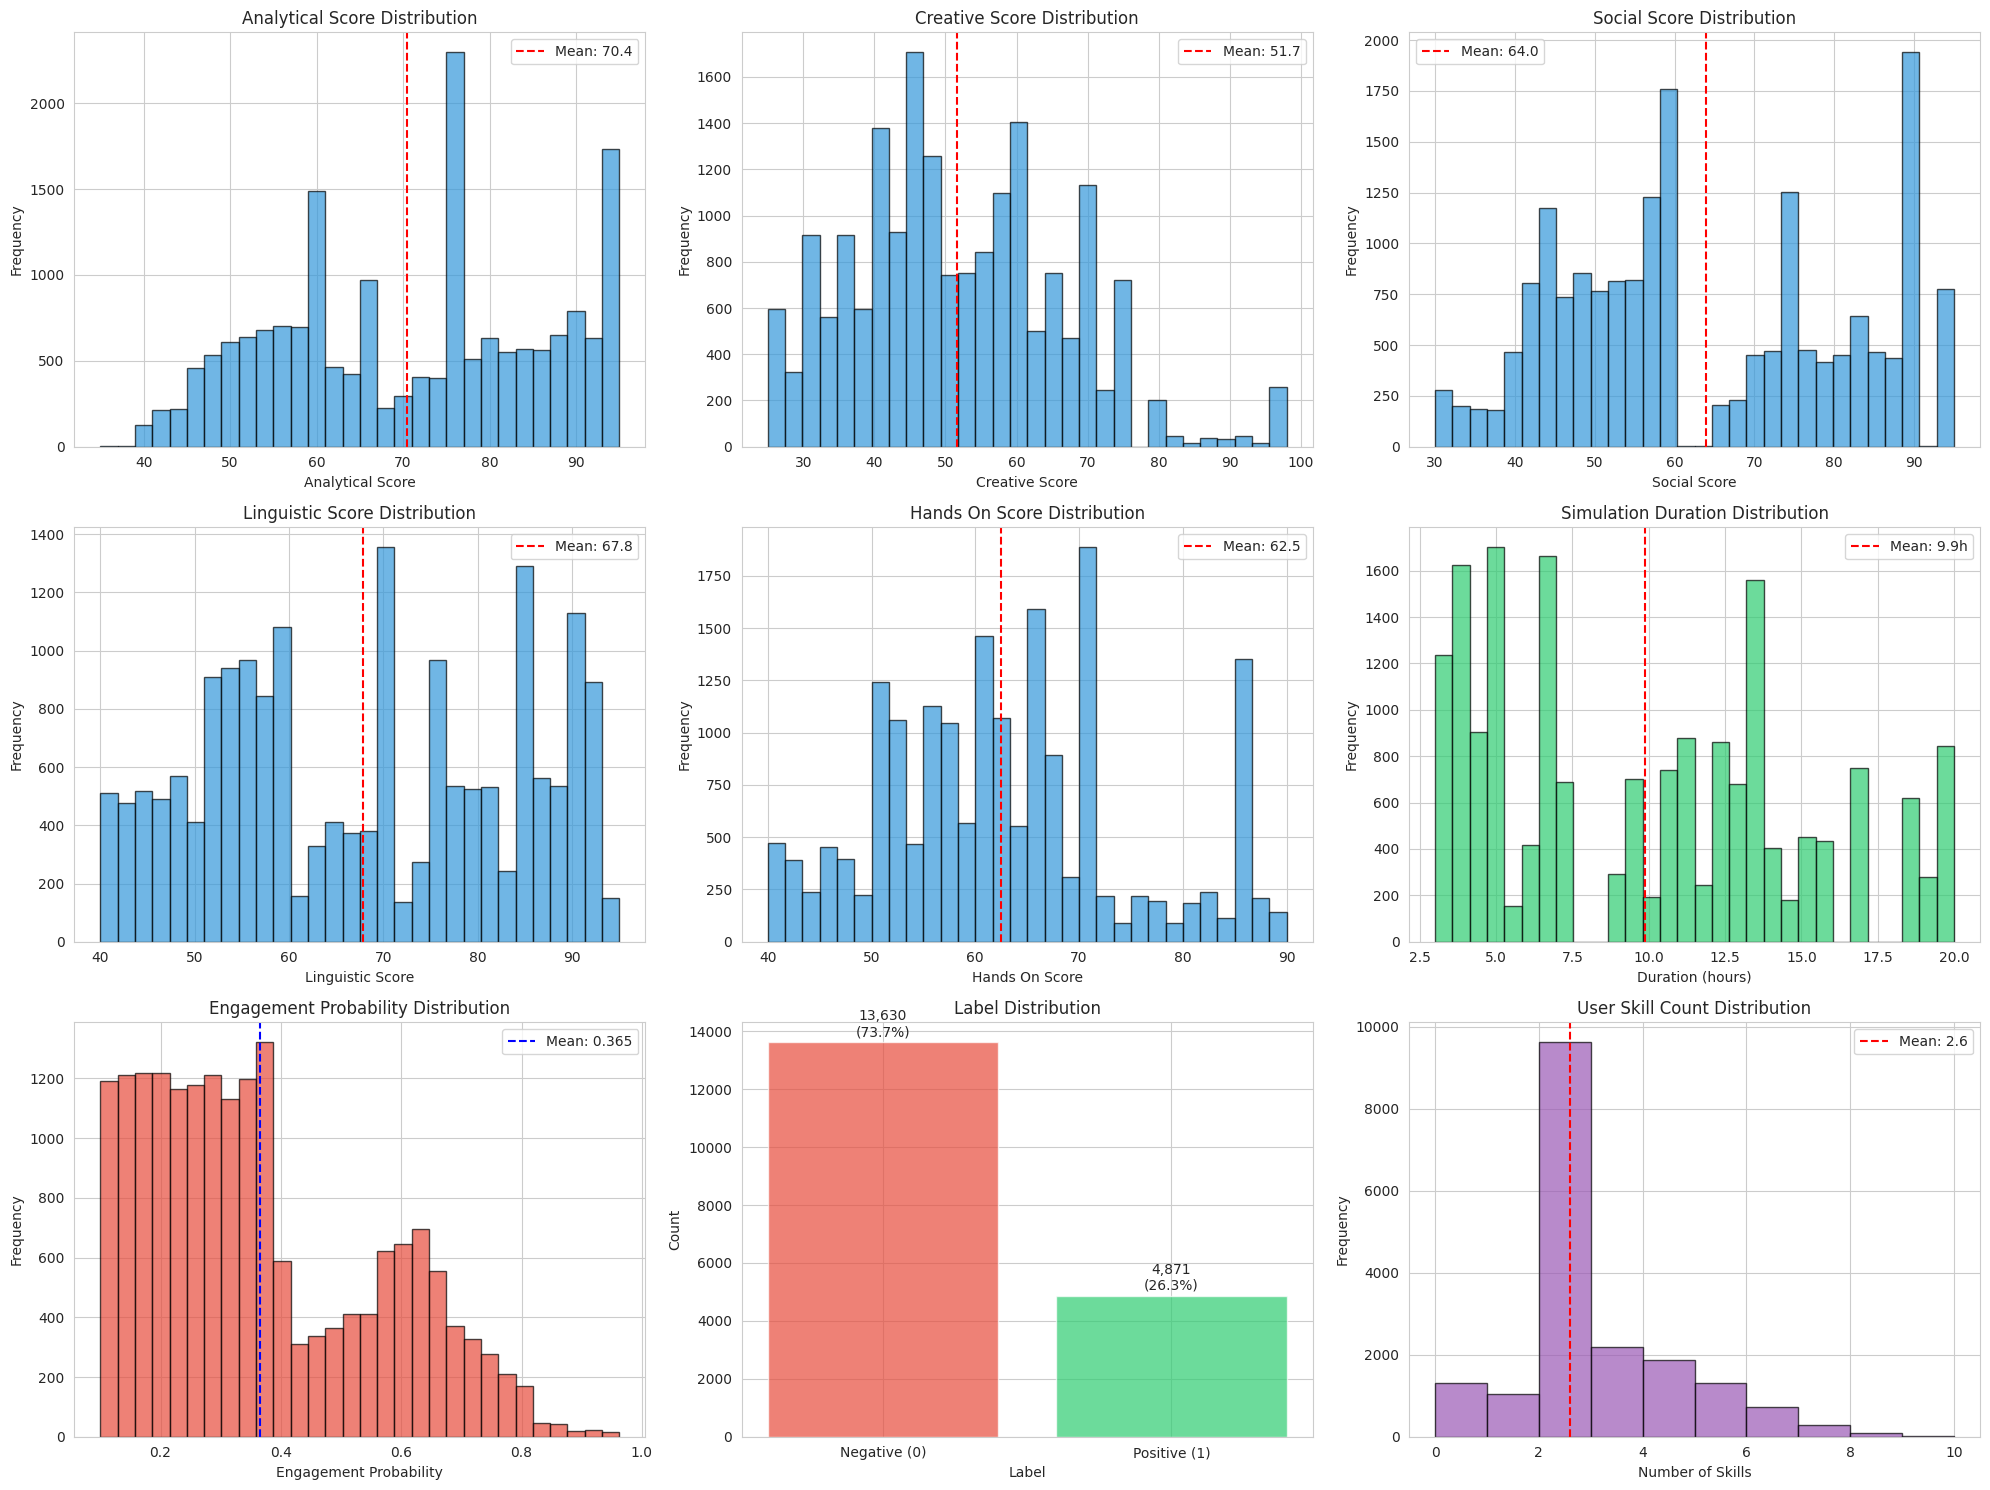


✓ Original data visualizations created


In [6]:
# Visualize original distributions
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Learning scores
score_features = ['analytical_score', 'creative_score', 'social_score', 
                  'linguistic_score', 'hands_on_score']
for idx, feature in enumerate(score_features):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[feature], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature.replace("_", " ").title()} Distribution')
    ax.axvline(df[feature].mean(), color='red', linestyle='--', 
               label=f'Mean: {df[feature].mean():.1f}')
    ax.legend()

# Duration
ax = axes[1, 2]
ax.hist(df['simulation_duracion_horas'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Frequency')
ax.set_title('Simulation Duration Distribution')
ax.axvline(df['simulation_duracion_horas'].mean(), color='red', linestyle='--',
           label=f'Mean: {df["simulation_duracion_horas"].mean():.1f}h')
ax.legend()

# Engagement probability
ax = axes[2, 0]
ax.hist(df['engagement_probability'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax.set_xlabel('Engagement Probability')
ax.set_ylabel('Frequency')
ax.set_title('Engagement Probability Distribution')
ax.axvline(df['engagement_probability'].mean(), color='blue', linestyle='--',
           label=f'Mean: {df["engagement_probability"].mean():.3f}')
ax.legend()

# Label distribution
ax = axes[2, 1]
label_counts = df['label'].value_counts().sort_index()
ax.bar(label_counts.index, label_counts.values, color=['#e74c3c', '#2ecc71'], alpha=0.7)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Label Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Skill counts
ax = axes[2, 2]
user_skill_counts = user_skill_vectors.sum(axis=1)
ax.hist(user_skill_counts, bins=range(int(user_skill_counts.min()), 
                                       int(user_skill_counts.max()) + 2), 
        color='#9b59b6', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Skills')
ax.set_ylabel('Frequency')
ax.set_title('User Skill Count Distribution')
ax.axvline(user_skill_counts.mean(), color='red', linestyle='--',
           label=f'Mean: {user_skill_counts.mean():.1f}')
ax.legend()

plt.tight_layout()
plt.savefig(viz_dir / '01_original_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Original data visualizations created")

---
## Step 3: Prepare Data for MindRecord

In [7]:
print("="*80)
print("PREPARING DATA FOR MINDRECORD")
print("="*80)

# Verify skill vector alignment
assert len(df) == len(user_skill_vectors), "User skill vectors length mismatch"
assert len(df) == len(sim_skill_vectors), "Simulation skill vectors length mismatch"
print("✓ Skill vectors aligned with dataframe")

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  WARNING: Found {missing.sum()} missing values:")
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count}")
    print("\nFilling missing values with defaults...")
    
    # Fill numeric with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Fill categorical with mode
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    print("✓ Missing values filled")
else:
    print("✓ No missing values found")

# Verify data types
print("\nData Type Verification:")
print(f"  Integer columns: {df.select_dtypes(include=['int64', 'int32']).shape[1]}")
print(f"  Float columns: {df.select_dtypes(include=['float64', 'float32']).shape[1]}")
print(f"  String columns: {df.select_dtypes(include=['object']).shape[1]}")

# Verify value ranges
print("\nValue Range Verification:")
score_cols = ['analytical_score', 'creative_score', 'social_score', 'linguistic_score', 'hands_on_score']
for col in score_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    status = "✓" if 0 <= min_val and max_val <= 100 else "✗"
    print(f"  {status} {col:25s}: [{min_val:6.2f}, {max_val:6.2f}]")

duration_min = df['simulation_duracion_horas'].min()
duration_max = df['simulation_duracion_horas'].max()
status = "✓" if 3 <= duration_min and duration_max <= 20 else "✗"
print(f"  {status} simulation_duracion_horas : [{duration_min:6.2f}, {duration_max:6.2f}]")

eng_min = df['engagement_probability'].min()
eng_max = df['engagement_probability'].max()
status = "✓" if 0 <= eng_min and eng_max <= 1 else "✗"
print(f"  {status} engagement_probability    : [{eng_min:6.3f}, {eng_max:6.3f}]")

print("\n✓ Data preparation complete")

PREPARING DATA FOR MINDRECORD
✓ Skill vectors aligned with dataframe
✓ No missing values found

Data Type Verification:
  Integer columns: 11
  Float columns: 2
  String columns: 9

Value Range Verification:
  ✓ analytical_score         : [ 35.00,  95.00]
  ✓ creative_score           : [ 25.00,  98.00]
  ✓ social_score             : [ 30.00,  95.00]
  ✓ linguistic_score         : [ 40.00,  95.00]
  ✓ hands_on_score           : [ 40.00,  90.00]
  ✓ simulation_duracion_horas : [  3.00,  20.00]
  ✓ engagement_probability    : [ 0.100,  0.962]

✓ Data preparation complete


---
## Step 4: Define MindRecord Schema

In [8]:
print("="*80)
print("DEFINING MINDRECORD SCHEMA")
print("="*80)

# Define schema for MindRecord
mindrecord_schema = {
    # Identifiers
    "user_id": {"type": "string"},
    "simulation_id": {"type": "string"},
    
    # Categorical features (encoded as int32)
    "education_level_encoded": {"type": "int32"},
    "field_of_study_encoded": {"type": "int32"},
    "simulation_categoria_encoded": {"type": "int32"},
    "simulation_nivel_dificultad_encoded": {"type": "int32"},
    "simulation_industria_encoded": {"type": "int32"},
    
    # Continuous features (int32 for learning scores, float32 for others)
    "analytical_score": {"type": "int32"},
    "creative_score": {"type": "int32"},
    "social_score": {"type": "int32"},
    "linguistic_score": {"type": "int32"},
    "hands_on_score": {"type": "int32"},
    "simulation_duracion_horas": {"type": "float32"},
    
    # Skill vectors (multi-hot encoding)
    "user_skills": {"type": "int32", "shape": [user_skill_vectors.shape[1]]},
    "simulation_skills": {"type": "int32", "shape": [sim_skill_vectors.shape[1]]},
    
    # Labels
    "label": {"type": "int32"},
    "engagement_probability": {"type": "float32"},
    
    # Metadata (optional, for tracking)
    "source_dataset": {"type": "string"},
    "sample_type": {"type": "string"},
}

print("Schema defined with {} fields:".format(len(mindrecord_schema)))
for field, spec in mindrecord_schema.items():
    if 'shape' in spec:
        print(f"  {field:40s}: {spec['type']:10s} shape={spec['shape']}")
    else:
        print(f"  {field:40s}: {spec['type']:10s}")

print(f"\n✓ MindRecord schema defined")
print(f"  Total fields: {len(mindrecord_schema)}")
print(f"  Skill vector dimensions: {user_skill_vectors.shape[1]}")

DEFINING MINDRECORD SCHEMA
Schema defined with 19 fields:
  user_id                                 : string    
  simulation_id                           : string    
  education_level_encoded                 : int32     
  field_of_study_encoded                  : int32     
  simulation_categoria_encoded            : int32     
  simulation_nivel_dificultad_encoded     : int32     
  simulation_industria_encoded            : int32     
  analytical_score                        : int32     
  creative_score                          : int32     
  social_score                            : int32     
  linguistic_score                        : int32     
  hands_on_score                          : int32     
  simulation_duracion_horas               : float32   
  user_skills                             : int32      shape=[52]
  simulation_skills                       : int32      shape=[52]
  label                                   : int32     
  engagement_probability                

---
## Step 5: Convert to MindRecord

In [9]:
print("="*80)
print("CONVERTING TO MINDRECORD FORMAT")
print("="*80)

# Output file
mindrecord_file = str(output_dir / 'widedeep_training.mindrecord')
print(f"\nOutput file: {mindrecord_file}")

# Remove existing file if present
for suffix in ['', '.db']:
    file_path = Path(mindrecord_file + suffix)
    if file_path.exists():
        file_path.unlink()
        print(f"  Removed existing: {file_path.name}")

# Create FileWriter
writer = FileWriter(file_name=mindrecord_file, shard_num=1)
print("\n✓ FileWriter created")

# Add schema
writer.add_schema(mindrecord_schema, "widedeep_training_schema")
print("✓ Schema added")

# Prepare data for writing
print("\nPreparing data samples...")
data_samples = []

for idx, row in df.iterrows():
    sample = {
        # Identifiers
        "user_id": str(row['user_id']),
        "simulation_id": str(row['simulation_id']),
        
        # Categorical (encoded)
        "education_level_encoded": int(row['education_level_encoded']),
        "field_of_study_encoded": int(row['field_of_study_encoded']),
        "simulation_categoria_encoded": int(row['simulation_categoria_encoded']),
        "simulation_nivel_dificultad_encoded": int(row['simulation_nivel_dificultad_encoded']),
        "simulation_industria_encoded": int(row['simulation_industria_encoded']),
        
        # Learning scores (int32)
        "analytical_score": int(row['analytical_score']),
        "creative_score": int(row['creative_score']),
        "social_score": int(row['social_score']),
        "linguistic_score": int(row['linguistic_score']),
        "hands_on_score": int(row['hands_on_score']),
        "simulation_duracion_horas": float(row['simulation_duracion_horas']),
        
        # Skill vectors (convert to list of int32)
        "user_skills": user_skill_vectors[idx].astype(np.int32),
        "simulation_skills": sim_skill_vectors[idx].astype(np.int32),
        
        # Labels
        "label": int(row['label']),
        "engagement_probability": float(row['engagement_probability']),
        
        # Metadata
        "source_dataset": str(row['source_dataset']),
        "sample_type": str(row['sample_type']),
    }
    
    data_samples.append(sample)
    
    # Progress indicator
    if (idx + 1) % 2000 == 0:
        print(f"  Prepared {idx + 1:,} / {len(df):,} samples...")

print(f"\n✓ Prepared {len(data_samples):,} samples")

# Write data
print("\nWriting to MindRecord file...")
writer.write_raw_data(data_samples)
print("✓ Data written")

# Commit
writer.commit()
print("✓ Write committed")

# Check file size
file_size_mb = Path(mindrecord_file).stat().st_size / (1024 * 1024)
print(f"\n✓ MindRecord file created successfully")
print(f"  File size: {file_size_mb:.2f} MB")
print(f"  Samples written: {len(data_samples):,}")
print(f"  Average bytes per sample: {(file_size_mb * 1024 * 1024) / len(data_samples):.1f}")

CONVERTING TO MINDRECORD FORMAT

Output file: /workspace/data/mindrecord/widedeep_training.mindrecord
  Removed existing: widedeep_training.mindrecord
  Removed existing: widedeep_training.mindrecord.db

✓ FileWriter created
✓ Schema added

Preparing data samples...
  Prepared 2,000 / 18,501 samples...
  Prepared 4,000 / 18,501 samples...
  Prepared 6,000 / 18,501 samples...
  Prepared 8,000 / 18,501 samples...
  Prepared 10,000 / 18,501 samples...
  Prepared 12,000 / 18,501 samples...
  Prepared 14,000 / 18,501 samples...
  Prepared 16,000 / 18,501 samples...
  Prepared 18,000 / 18,501 samples...

✓ Prepared 18,501 samples

Writing to MindRecord file...
✓ Data written
✓ Write committed

✓ MindRecord file created successfully
  File size: 55.30 MB
  Samples written: 18,501
  Average bytes per sample: 3134.4


---
## Step 6: Read Back & Verify Conversion

In [10]:
print("="*80)
print("READING BACK FROM MINDRECORD")
print("="*80)

# Use MindDataset instead of FileReader for reliable reading
from mindspore import dataset as ds

# Read from MindRecord using MindDataset
print(f"\nLoading MindRecord file...")
data_set = ds.MindDataset(
    dataset_files=mindrecord_file,
    columns_list=None,  # Load all columns
    shuffle=False
)

print(f"✓ MindDataset created")

# Count samples and collect first few
sample_count = 0
first_samples = []

print(f"\nReading samples...")
for sample in data_set.create_dict_iterator(num_epochs=1, output_numpy=True):
    sample_count += 1
    
    if sample_count <= 5:
        first_samples.append(sample)
    
    # Progress indicator
    if sample_count % 2000 == 0:
        print(f"  Read {sample_count:,} samples...")

print(f"\n✓ Read {sample_count:,} samples from MindRecord")

# Verify count
if sample_count == len(df):
    print(f"✅ SUCCESS: Sample count matches ({sample_count:,} == {len(df):,})")
else:
    print(f"❌ ERROR: Sample count mismatch ({sample_count:,} != {len(df):,})")

# Inspect first sample
print("\n" + "="*80)
print("SAMPLE RECORD INSPECTION")
print("="*80)

if first_samples:
    sample = first_samples[0]
    print("\nFirst sample fields:")
    for key in sorted(sample.keys()):
        value = sample[key]
        if isinstance(value, np.ndarray):
            if len(value.shape) > 0 and value.shape[0] > 10:
                print(f"  {key:40s}: array shape={value.shape}, dtype={value.dtype}")
                print(f"    First 10 elements: {value[:10]}")
            else:
                print(f"  {key:40s}: {value} (shape={value.shape}, dtype={value.dtype})")
        else:
            print(f"  {key:40s}: {value}")
else:
    print("⚠️  No samples to inspect")

print("\n✓ Read-back verification complete")

READING BACK FROM MINDRECORD

Loading MindRecord file...
✓ MindDataset created

Reading samples...
  Read 2,000 samples...
  Read 4,000 samples...
  Read 6,000 samples...
  Read 8,000 samples...
  Read 10,000 samples...
  Read 12,000 samples...
  Read 14,000 samples...
  Read 16,000 samples...
  Read 18,000 samples...

✓ Read 18,501 samples from MindRecord
✅ SUCCESS: Sample count matches (18,501 == 18,501)

SAMPLE RECORD INSPECTION

First sample fields:
  analytical_score                        : 76 (shape=(), dtype=int32)
  creative_score                          : 49 (shape=(), dtype=int32)
  education_level_encoded                 : 0 (shape=(), dtype=int32)
  engagement_probability                  : 0.793571412563324 (shape=(), dtype=float32)
  field_of_study_encoded                  : 3 (shape=(), dtype=int32)
  hands_on_score                          : 70 (shape=(), dtype=int32)
  label                                   : 1 (shape=(), dtype=int32)
  linguistic_score             

---
## Step 7: Quality Verification - Compare Statistics

In [11]:
print("="*80)
print("QUALITY VERIFICATION - STATISTICAL COMPARISON")
print("="*80)

# Read all data from MindRecord for comparison using MindDataset
from mindspore import dataset as ds

data_set = ds.MindDataset(
    dataset_files=mindrecord_file,
    columns_list=None,
    shuffle=False
)

mindrecord_data = {
    'analytical_score': [],
    'creative_score': [],
    'social_score': [],
    'linguistic_score': [],
    'hands_on_score': [],
    'simulation_duracion_horas': [],
    'engagement_probability': [],
    'label': [],
    'user_skills_sum': [],
    'simulation_skills_sum': []
}

print("\nReading all samples from MindRecord for comparison...")
count = 0
for sample in data_set.create_dict_iterator(num_epochs=1, output_numpy=True):
    mindrecord_data['analytical_score'].append(sample['analytical_score'])
    mindrecord_data['creative_score'].append(sample['creative_score'])
    mindrecord_data['social_score'].append(sample['social_score'])
    mindrecord_data['linguistic_score'].append(sample['linguistic_score'])
    mindrecord_data['hands_on_score'].append(sample['hands_on_score'])
    mindrecord_data['simulation_duracion_horas'].append(sample['simulation_duracion_horas'])
    mindrecord_data['engagement_probability'].append(sample['engagement_probability'])
    mindrecord_data['label'].append(sample['label'])
    mindrecord_data['user_skills_sum'].append(sample['user_skills'].sum())
    mindrecord_data['simulation_skills_sum'].append(sample['simulation_skills'].sum())
    
    count += 1
    if count % 2000 == 0:
        print(f"  Read {count:,} samples...")

print(f"✓ Read {count:,} samples")

# Convert to arrays
for key in mindrecord_data:
    mindrecord_data[key] = np.array(mindrecord_data[key])

# Compare statistics
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

comparison_features = ['analytical_score', 'creative_score', 'social_score',
                       'linguistic_score', 'hands_on_score', 'simulation_duracion_horas',
                       'engagement_probability']

print(f"\n{'Feature':<35} {'Original Mean':<15} {'MindRecord Mean':<15} {'Diff':<10} {'Status'}")
print("-" * 90)

all_match = True
for feature in comparison_features:
    orig_mean = df[feature].mean()
    mr_mean = mindrecord_data[feature].mean()
    diff = abs(orig_mean - mr_mean)
    status = "✓" if diff < 0.01 else "✗"
    
    if diff >= 0.01:
        all_match = False
    
    print(f"{feature:<35} {orig_mean:<15.4f} {mr_mean:<15.4f} {diff:<10.6f} {status}")

# Label distribution
print("\n" + "="*80)
print("LABEL DISTRIBUTION COMPARISON")
print("="*80)

orig_label_dist = df['label'].value_counts().sort_index()
mr_label_dist = Counter(mindrecord_data['label'])

print(f"\n{'Label':<10} {'Original':<15} {'MindRecord':<15} {'Match'}")
print("-" * 50)
for label in [0, 1]:
    orig_count = orig_label_dist.get(label, 0)
    mr_count = mr_label_dist.get(label, 0)
    match = "✓" if orig_count == mr_count else "✗"
    print(f"{label:<10} {orig_count:<15,} {mr_count:<15,} {match}")

# Skill vector statistics
print("\n" + "="*80)
print("SKILL VECTOR COMPARISON")
print("="*80)

orig_user_skills = user_skill_vectors.sum(axis=1)
mr_user_skills = mindrecord_data['user_skills_sum']

print(f"\nUser Skills per Sample:")
print(f"  Original mean: {orig_user_skills.mean():.2f}")
print(f"  MindRecord mean: {mr_user_skills.mean():.2f}")
print(f"  Difference: {abs(orig_user_skills.mean() - mr_user_skills.mean()):.6f}")

orig_sim_skills = sim_skill_vectors.sum(axis=1)
mr_sim_skills = mindrecord_data['simulation_skills_sum']

print(f"\nSimulation Skills per Sample:")
print(f"  Original mean: {orig_sim_skills.mean():.2f}")
print(f"  MindRecord mean: {mr_sim_skills.mean():.2f}")
print(f"  Difference: {abs(orig_sim_skills.mean() - mr_sim_skills.mean()):.6f}")

if all_match:
    print("\n" + "="*80)
    print("✅ CONVERSION QUALITY: EXCELLENT")
    print("="*80)
    print("All statistics match perfectly. Data integrity maintained.")
else:
    print("\n" + "="*80)
    print("⚠️  CONVERSION QUALITY: CHECK DIFFERENCES")
    print("="*80)
    print("Some statistics differ. Review the comparison above.")

QUALITY VERIFICATION - STATISTICAL COMPARISON

Reading all samples from MindRecord for comparison...
  Read 2,000 samples...
  Read 4,000 samples...
  Read 6,000 samples...
  Read 8,000 samples...
  Read 10,000 samples...
  Read 12,000 samples...
  Read 14,000 samples...
  Read 16,000 samples...
  Read 18,000 samples...
✓ Read 18,501 samples

STATISTICAL COMPARISON

Feature                             Original Mean   MindRecord Mean Diff       Status
------------------------------------------------------------------------------------------
analytical_score                    70.4380         70.4380         0.000000   ✓
creative_score                      51.6924         51.6924         0.000000   ✓
social_score                        63.9885         63.9885         0.000000   ✓
linguistic_score                    67.8070         67.8070         0.000000   ✓
hands_on_score                      62.4642         62.4642         0.000000   ✓
simulation_duracion_horas           9.8732       

---
## Step 8: Visual Comparison - Original vs MindRecord

VISUAL COMPARISON - ORIGINAL VS MINDRECORD


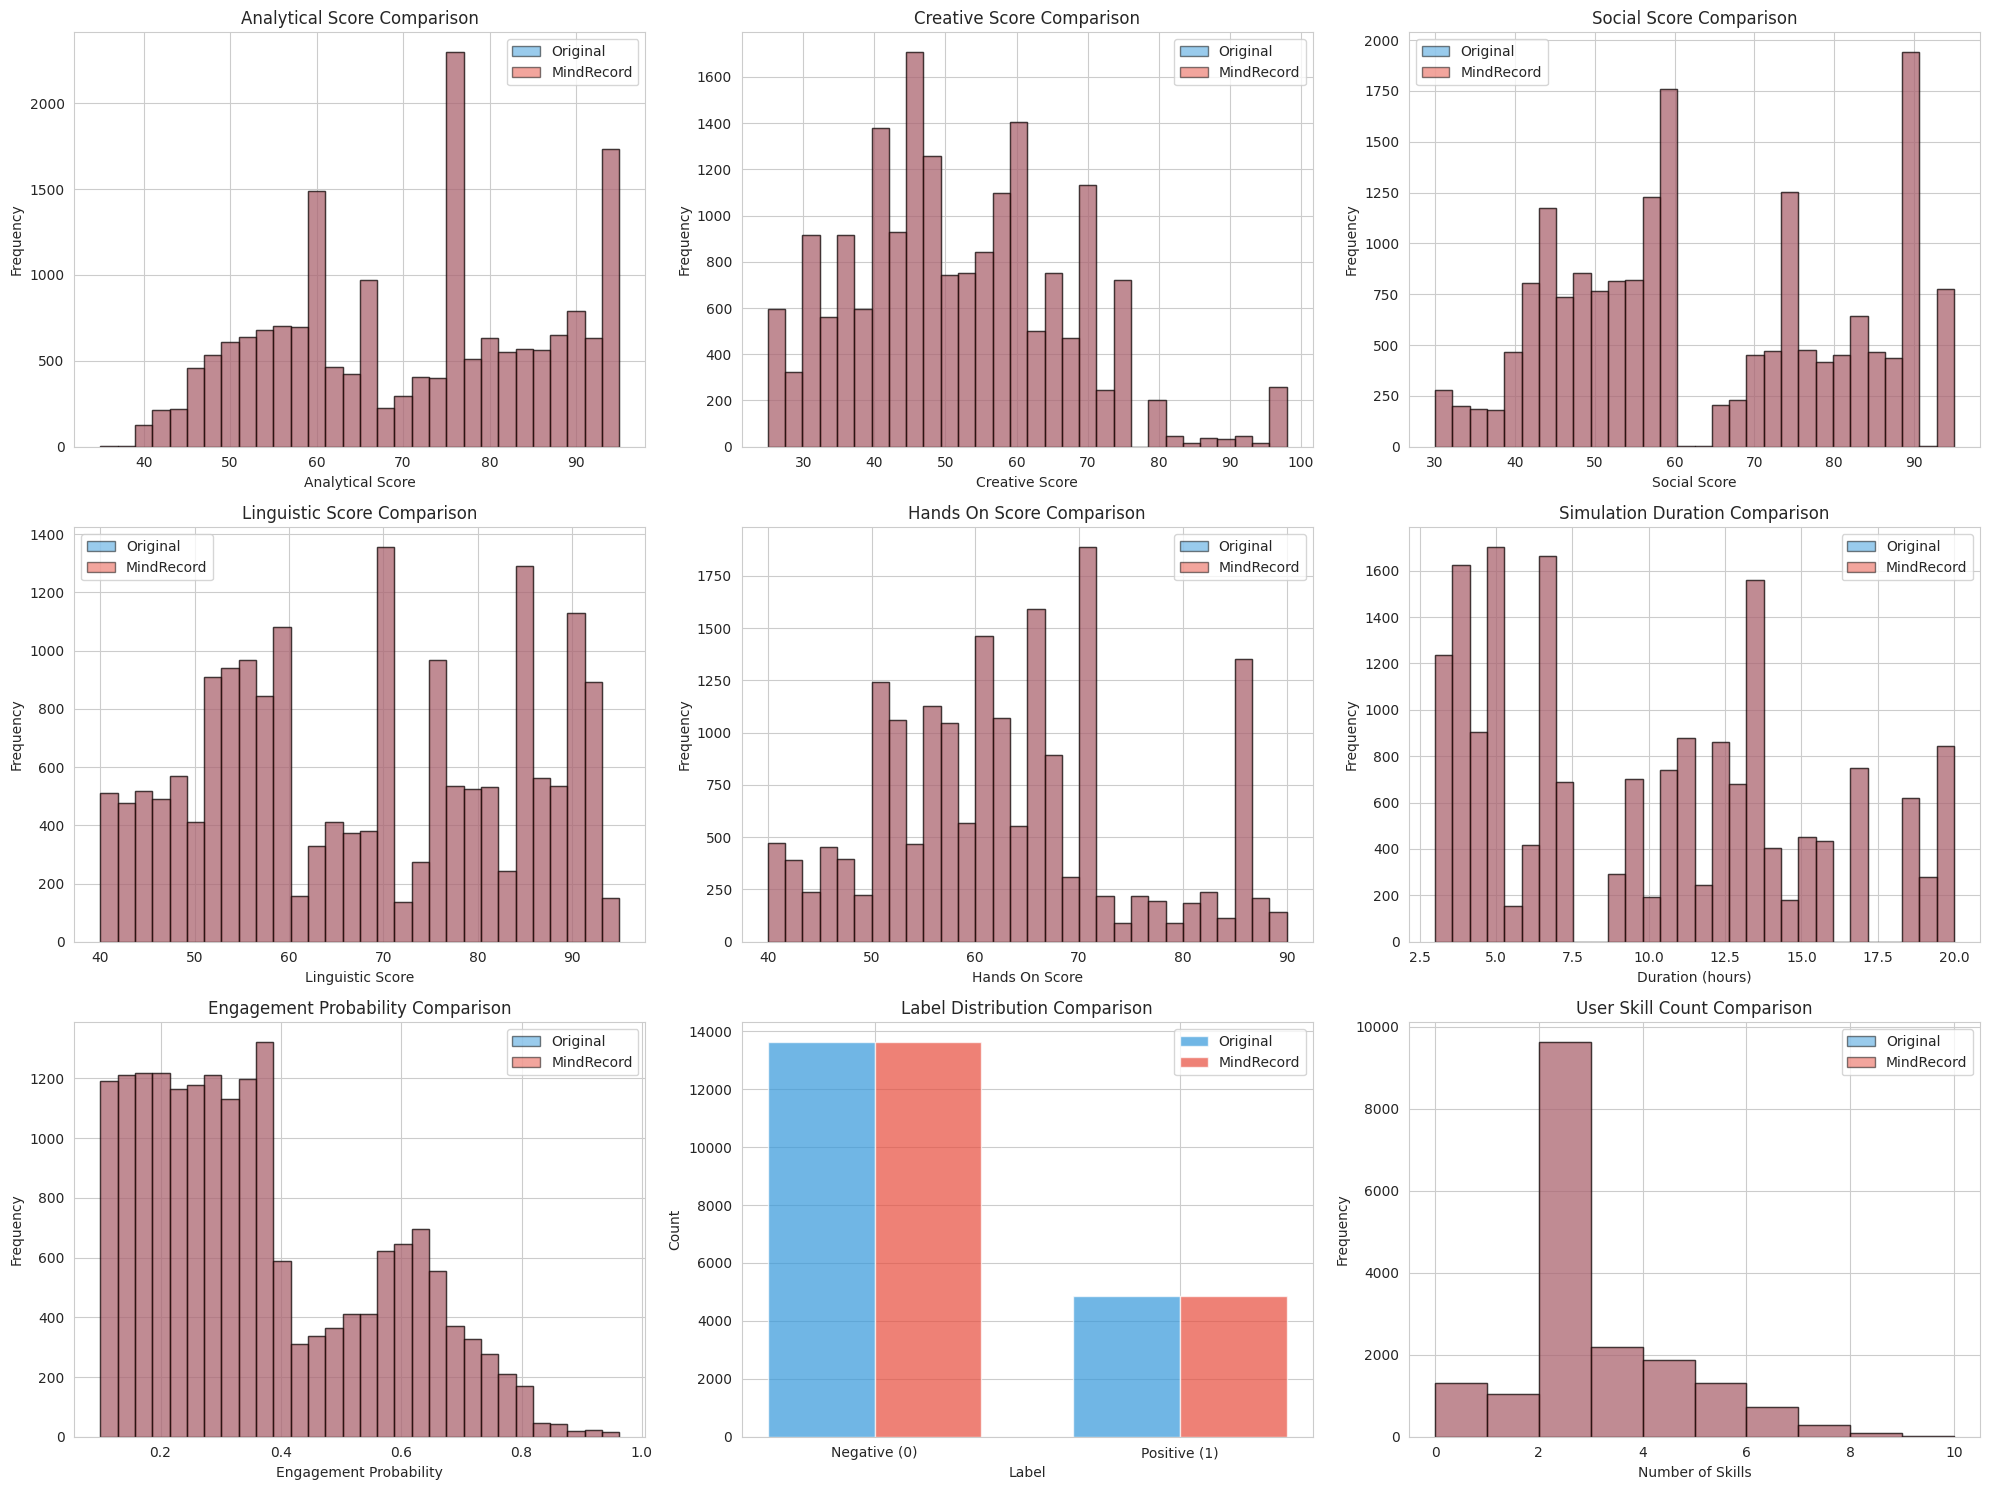


✓ Visual comparison complete


In [12]:
print("="*80)
print("VISUAL COMPARISON - ORIGINAL VS MINDRECORD")
print("="*80)

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Learning scores comparison
score_features = ['analytical_score', 'creative_score', 'social_score',
                  'linguistic_score', 'hands_on_score']

for idx, feature in enumerate(score_features):
    ax = axes[idx // 3, idx % 3]
    
    # Original
    ax.hist(df[feature], bins=30, alpha=0.5, color='#3498db', 
            label='Original', edgecolor='black')
    
    # MindRecord
    ax.hist(mindrecord_data[feature], bins=30, alpha=0.5, color='#e74c3c',
            label='MindRecord', edgecolor='black')
    
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature.replace("_", " ").title()} Comparison')
    ax.legend()

# Duration comparison
ax = axes[1, 2]
ax.hist(df['simulation_duracion_horas'], bins=30, alpha=0.5, color='#3498db',
        label='Original', edgecolor='black')
ax.hist(mindrecord_data['simulation_duracion_horas'], bins=30, alpha=0.5, color='#e74c3c',
        label='MindRecord', edgecolor='black')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Frequency')
ax.set_title('Simulation Duration Comparison')
ax.legend()

# Engagement probability
ax = axes[2, 0]
ax.hist(df['engagement_probability'], bins=30, alpha=0.5, color='#3498db',
        label='Original', edgecolor='black')
ax.hist(mindrecord_data['engagement_probability'], bins=30, alpha=0.5, color='#e74c3c',
        label='MindRecord', edgecolor='black')
ax.set_xlabel('Engagement Probability')
ax.set_ylabel('Frequency')
ax.set_title('Engagement Probability Comparison')
ax.legend()

# Label distribution comparison
ax = axes[2, 1]
x = [0, 1]
width = 0.35
orig_counts = [orig_label_dist.get(0, 0), orig_label_dist.get(1, 0)]
mr_counts = [mr_label_dist.get(0, 0), mr_label_dist.get(1, 0)]
ax.bar([i - width/2 for i in x], orig_counts, width, label='Original', color='#3498db', alpha=0.7)
ax.bar([i + width/2 for i in x], mr_counts, width, label='MindRecord', color='#e74c3c', alpha=0.7)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Label Distribution Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
ax.legend()

# Skill count comparison
ax = axes[2, 2]
ax.hist(orig_user_skills, bins=range(int(orig_user_skills.min()),
                                      int(orig_user_skills.max()) + 2),
        alpha=0.5, color='#3498db', label='Original', edgecolor='black')
ax.hist(mr_user_skills, bins=range(int(mr_user_skills.min()),
                                    int(mr_user_skills.max()) + 2),
        alpha=0.5, color='#e74c3c', label='MindRecord', edgecolor='black')
ax.set_xlabel('Number of Skills')
ax.set_ylabel('Frequency')
ax.set_title('User Skill Count Comparison')
ax.legend()

plt.tight_layout()
plt.savefig(viz_dir / '02_original_vs_mindrecord.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visual comparison complete")

---
## Step 9: Save Metadata & Summary

In [13]:
import json
from datetime import datetime

print("="*80)
print("SAVING CONVERSION METADATA")
print("="*80)

metadata = {
    "conversion_timestamp": datetime.now().isoformat(),
    "original_data": {
        "csv_file": "unified_training_dataset_v3.csv",
        "total_samples": int(len(df)),
        "positive_samples": int(df['label'].sum()),
        "negative_samples": int((df['label'] == 0).sum()),
        "positive_rate": float(df['label'].mean()),
        "unique_users": int(df['user_id'].nunique()),
        "unique_simulations": int(df['simulation_id'].nunique()),
    },
    "mindrecord_output": {
        "file_name": "widedeep_training.mindrecord",
        "file_size_mb": float(file_size_mb),
        "samples_written": int(sample_count),
        "shard_num": 1,
    },
    "schema": {
        "total_fields": len(mindrecord_schema),
        "skill_vector_dimensions": int(user_skill_vectors.shape[1]),
        "categorical_features": [
            "education_level_encoded",
            "field_of_study_encoded",
            "simulation_categoria_encoded",
            "simulation_nivel_dificultad_encoded",
            "simulation_industria_encoded"
        ],
        "continuous_features": [
            "analytical_score", "creative_score", "social_score",
            "linguistic_score", "hands_on_score", "simulation_duracion_horas"
        ],
        "skill_features": ["user_skills", "simulation_skills"],
        "labels": ["label", "engagement_probability"]
    },
    "verification": {
        "sample_count_match": sample_count == len(df),
        "statistics_match": all_match,
        "quality_check": "PASS" if (sample_count == len(df) and all_match) else "REVIEW"
    }
}

# Save metadata
metadata_file = output_dir / 'mindrecord_conversion_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Metadata saved to: {metadata_file}")

# Print summary
print("\n" + "="*80)
print("CONVERSION SUMMARY")
print("="*80)

print(f"\nOriginal Dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Positive rate: {df['label'].mean()*100:.2f}%")
print(f"  Unique users: {df['user_id'].nunique():,}")

print(f"\nMindRecord Output:")
print(f"  File: {mindrecord_file}")
print(f"  Size: {file_size_mb:.2f} MB")
print(f"  Samples: {sample_count:,}")

print(f"\nQuality Verification:")
print(f"  Sample count match: {'✓' if sample_count == len(df) else '✗'}")
print(f"  Statistics match: {'✓' if all_match else '✗'}")
print(f"  Overall status: {metadata['verification']['quality_check']}")

if metadata['verification']['quality_check'] == 'PASS':
    print("\n" + "="*80)
    print("✅ CONVERSION SUCCESSFUL")
    print("="*80)
    print("MindRecord file is ready for training!")
else:
    print("\n" + "="*80)
    print("⚠️  CONVERSION NEEDS REVIEW")
    print("="*80)
    print("Check the comparison statistics above for details.")

SAVING CONVERSION METADATA

✓ Metadata saved to: /workspace/data/mindrecord/mindrecord_conversion_metadata.json

CONVERSION SUMMARY

Original Dataset:
  Samples: 18,501
  Positive rate: 26.33%
  Unique users: 6,167

MindRecord Output:
  File: /workspace/data/mindrecord/widedeep_training.mindrecord
  Size: 55.30 MB
  Samples: 18,501

Quality Verification:
  Sample count match: ✓
  Statistics match: ✓
  Overall status: PASS

✅ CONVERSION SUCCESSFUL
MindRecord file is ready for training!


---
## Step 10: Usage Example - Load MindRecord for Training

In [14]:
print("="*80)
print("USAGE EXAMPLE - LOADING FOR TRAINING")
print("="*80)

print("\n# Example code to load MindRecord in training:")
print("""
from mindspore import dataset as ds

# Create dataset from MindRecord
data_set = ds.MindDataset(
    dataset_files='widedeep_training.mindrecord',
    columns_list=None,  # Load all columns
    num_parallel_workers=4,
    shuffle=True
)

# Batch the data
data_set = data_set.batch(batch_size=256)

# Iterate through batches
for batch in data_set.create_dict_iterator():
    # Access features
    user_skills = batch['user_skills']  # shape: (256, 52)
    sim_skills = batch['simulation_skills']  # shape: (256, 52)
    analytical = batch['analytical_score']  # shape: (256,)
    labels = batch['label']  # shape: (256,)
    
    # Feed to model...
    break
""")

print("\n✓ See example code above for loading in training")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
print(f"\n1. MindRecord file: {output_dir / 'widedeep_training.mindrecord'}")
print(f"2. MindRecord database: {output_dir / 'widedeep_training.mindrecord.db'}")
print(f"3. Conversion metadata: {output_dir / 'mindrecord_conversion_metadata.json'}")
print(f"4. Visualization 1: {viz_dir / '01_original_data_distribution.png'}")
print(f"5. Visualization 2: {viz_dir / '02_original_vs_mindrecord.png'}")

print("\n✓ All files generated successfully")

USAGE EXAMPLE - LOADING FOR TRAINING

# Example code to load MindRecord in training:

from mindspore import dataset as ds

# Create dataset from MindRecord
data_set = ds.MindDataset(
    dataset_files='widedeep_training.mindrecord',
    columns_list=None,  # Load all columns
    num_parallel_workers=4,
    shuffle=True
)

# Batch the data
data_set = data_set.batch(batch_size=256)

# Iterate through batches
for batch in data_set.create_dict_iterator():
    # Access features
    user_skills = batch['user_skills']  # shape: (256, 52)
    sim_skills = batch['simulation_skills']  # shape: (256, 52)
    analytical = batch['analytical_score']  # shape: (256,)
    labels = batch['label']  # shape: (256,)
    
    # Feed to model...
    break


✓ See example code above for loading in training

FILES GENERATED

1. MindRecord file: /workspace/data/mindrecord/widedeep_training.mindrecord
2. MindRecord database: /workspace/data/mindrecord/widedeep_training.mindrecord.db
3. Conversion metadata: /wor